## Julieta Madrigal Flores

## Rodolfo Del Castillo Wilches

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
from datetime import date


In [ ]:
ticker = 'GLD'
fecha_ref = '2026-04-16'   # fecha de referencia del proyecto
fecha_vencimiento = '2026-05-15'  # fecha de vencimiento del Iron Condor

# Descarga histórica hasta la fecha de referencia
data = yf.download(ticker, start='2025-01-01', end='2026-04-17', progress=False)['Close']

# S0: precio de cierre del 16 de abril de 2026
S0 = float(data.loc['2026-04-16'])

# Volatilidad histórica anualizada
returns    = np.log(data / data.shift(1)).dropna()
sigma_hist = float(returns.std() * np.sqrt(252))

# Parámetros del modelo
# r: tasa libre de riesgo (T-Bill 3 meses al 16 de abril de 2026)
r = 0.0361

# sigma: usamos la volatilidad histórica calculada de GLD
# Se valida contra el GVZ (CBOE Gold ETF Volatility Index) ~27% en abril 2026
sigma = sigma_hist

# T: días calendario entre fecha de referencia y vencimiento
T = (date(2026, 5, 15) - date(2026, 4, 16)).days / 365

print(f"  Ticker                   : {ticker}")
print(f"  Fecha de referencia      : {fecha_ref}")
print(f"  Fecha de vencimiento     : {fecha_vencimiento}")
print(f"  Precio spot GLD (S0)     : ${S0:.2f}")
print(f"  Volatilidad histórica (σ): {sigma:.2%}")
print(f"  Tasa libre de riesgo (r) : {r:.2%}  [FRED DTB3, 16 abr 2026]")
print(f"  Tiempo al vencimiento (T): {T:.4f} años ({round(T*365)} días)")

/tmp/ipykernel_3942/1228813201.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2025-01-01', end='2026-04-17', progress=False)['Close']


  Ticker                   : GLD
  Fecha de referencia      : 2026-04-16
  Fecha de vencimiento     : 2026-05-15
  Precio spot GLD (S0)     : $440.08
  Volatilidad histórica (σ): 25.64%
  Tasa libre de riesgo (r) : 3.61%  [FRED DTB3, 16 abr 2026]
  Tiempo al vencimiento (T): 0.0795 años (29 días)


/tmp/ipykernel_3942/1228813201.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data.loc['2026-04-16'])
/tmp/ipykernel_3942/1228813201.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_hist = float(returns.std() * np.sqrt(252))


In [ ]:
# FUNCIÓN BLACK-SCHOLES

def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [ ]:
# FUNCIONES DE GRIEGAS

def bs_greeks(S, K, r, T, sigma, option="call"):
    """Calcula las 4 griegas principales de una opción."""
    if sigma <= 0 or T <= 0:
        return {"delta": 0, "gamma": 0, "theta": 0, "vega": 0}

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Delta
    if option == "call":
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1

    # Gamma (igual para call y put)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Theta (por día calendario, dividida entre 365)
    if option == "call":
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

    # Vega (por 1% de cambio en sigma)
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    return {"delta": delta, "gamma": gamma, "theta": theta, "vega": vega}

In [ ]:
#  FUNCIONES DE PAYOFF

def payoff_estrategia(S_range, legs):
    """Calcula el P&L neto al vencimiento para una estrategia multi-pierna."""
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica el P&L con formato estándar de la clase."""
    plt.figure(figsize=(11, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2, label='P&L Iron Condor')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if S0:
        plt.axvline(S0, color='purple', linewidth=1.2, linestyle='-.', label=f'S0=${S0:.2f}')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# CONSTRUCCIÓN DEL IRON CONDOR

# Strikes seleccionados por criterio de 1.5 y 2 desviaciones estándar
mov_1sigma = S0 * sigma * np.sqrt(T)

K1 = 390.0   # Long Put  (protección bajista)
K2 = 415.0   # Short Put (vendida)
K3 = 465.0   # Short Call (vendida)
K4 = 490.0   # Long Call (protección alcista)

# Primas teóricas Black-Scholes para cada pierna
P_K1 = bs_price(S0, K1, r, T, sigma, option="put")
P_K2 = bs_price(S0, K2, r, T, sigma, option="put")
C_K3 = bs_price(S0, K3, r, T, sigma, option="call")
C_K4 = bs_price(S0, K4, r, T, sigma, option="call")

print("\n" + "=" * 60)
print("PRIMAS TEÓRICAS BLACK-SCHOLES (por acción)")
print("=" * 60)
print(f"  Long Put  K1 = ${K1:.0f}  →  prima = ${P_K1:.4f}")
print(f"  Short Put K2 = ${K2:.0f}  →  prima = ${P_K2:.4f}")
print(f"  Short Call K3 = ${K3:.0f}  →  prima = ${C_K3:.4f}")
print(f"  Long Call  K4 = ${K4:.0f}  →  prima = ${C_K4:.4f}")



PRIMAS TEÓRICAS BLACK-SCHOLES (por acción)
  Long Put  K1 = $390  →  prima = $0.5313
  Short Put K2 = $415  →  prima = $3.3796
  Short Call K3 = $465  →  prima = $4.4868
  Long Call  K4 = $490  →  prima = $1.1058


In [ ]:
# Crédito neto
credito_pcs = P_K2 - P_K1   # crédito del Put Credit Spread
credito_ccs = C_K3 - C_K4   # crédito del Call Credit Spread
credito_neto = credito_pcs + credito_ccs

perdida_max   = (K2 - K1) - credito_neto
be_bajista    = K2 - credito_neto
be_alcista    = K3 + credito_neto

print("\n" + "=" * 60)
print("MÉTRICAS DEL IRON CONDOR")
print("=" * 60)
print(f"  Crédito neto (ganancia máx.) : ${credito_neto:.4f} por acción")
print(f"  Crédito neto por contrato    : ${credito_neto * 100:.2f}")
print(f"  Pérdida máxima por acción    : ${perdida_max:.4f}")
print(f"  Pérdida máxima por contrato  : ${perdida_max * 100:.2f}")
print(f"  Break-even bajista           : ${be_bajista:.4f}")
print(f"  Break-even alcista           : ${be_alcista:.4f}")
print(f"  Zona de ganancia             : [${K2:.0f}, ${K3:.0f}]")


MÉTRICAS DEL IRON CONDOR
  Crédito neto (ganancia máx.) : $6.2293 por acción
  Crédito neto por contrato    : $622.93
  Pérdida máxima por acción    : $18.7707
  Pérdida máxima por contrato  : $1877.07
  Break-even bajista           : $408.7707
  Break-even alcista           : $471.2293
  Zona de ganancia             : [$415, $465]


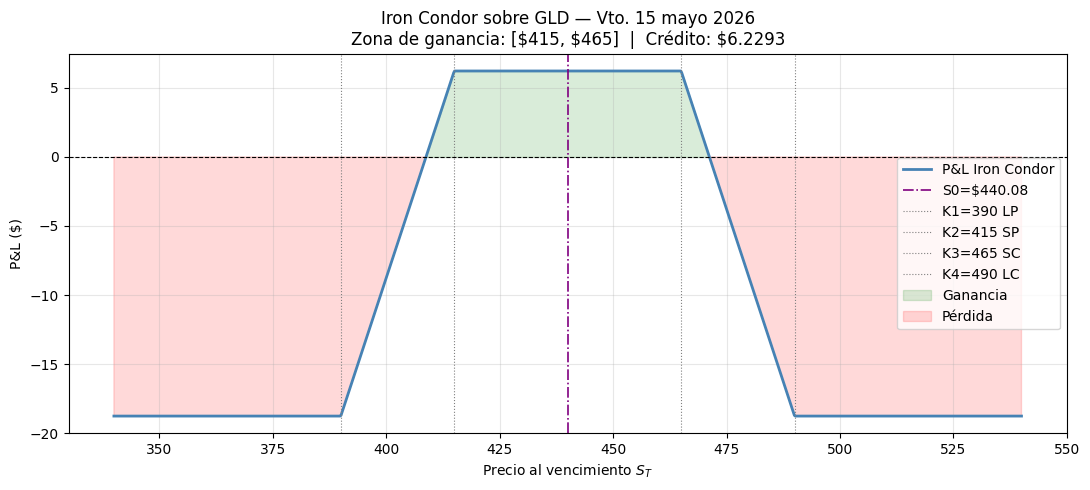

In [ ]:
# DIAGRAMA DE PAYOFF
legs_condor = [
    {'tipo': 'put',  'K': K1, 'prima': P_K1, 'posicion': +1},  # Long Put
    {'tipo': 'put',  'K': K2, 'prima': P_K2, 'posicion': -1},  # Short Put
    {'tipo': 'call', 'K': K3, 'prima': C_K3, 'posicion': -1},  # Short Call
    {'tipo': 'call', 'K': K4, 'prima': C_K4, 'posicion': +1},  # Long Call
    ]

S_range = np.linspace(340, 540, 1000)
pnl     = payoff_estrategia(S_range, legs_condor)

graficar_estrategia(
    S_range, pnl,
    f'Iron Condor sobre GLD — Vto. 15 mayo 2026\n'
    f'Zona de ganancia: [${K2:.0f}, ${K3:.0f}]  |  Crédito: ${credito_neto:.4f}',
    S0=S0,
    K_lines=[(K1, f'K1={K1:.0f} LP'), (K2, f'K2={K2:.0f} SP'),
             (K3, f'K3={K3:.0f} SC'), (K4, f'K4={K4:.0f} LC')])

In [ ]:
# GRIEGAS DEL PORTAFOLIO

posiciones = [
    (+1, K1, "put"),
    (-1, K2, "put"),
    (-1, K3, "call"),
    (+1, K4, "call"),
]

delta_total = gamma_total = theta_total = vega_total = 0.0
rows = []

for pos, K, tipo in posiciones:
    g = bs_greeks(S0, K, r, T, sigma, option=tipo)
    rows.append({
        "Pierna":  f"{'Long' if pos>0 else 'Short'} {tipo.capitalize()} K={K:.0f}",
        "Posición": pos,
        "Delta":  round(pos * g["delta"], 6),
        "Gamma":  round(pos * g["gamma"], 6),
        "Theta":  round(pos * g["theta"], 6),
        "Vega":   round(pos * g["vega"],  6),
    })
    delta_total += pos * g["delta"]
    gamma_total += pos * g["gamma"]
    theta_total += pos * g["theta"]
    vega_total  += pos * g["vega"]

df_greeks = pd.DataFrame(rows)
totales   = pd.DataFrame([{
    "Pierna": "PORTAFOLIO TOTAL", "Posición": "",
    "Delta": round(delta_total, 6), "Gamma": round(gamma_total, 6),
    "Theta": round(theta_total, 6), "Vega":  round(vega_total,  6),
}])
df_greeks = pd.concat([df_greeks, totales], ignore_index=True)

print("\n" + "=" * 60)
print("GRIEGAS DEL PORTAFOLIO IRON CONDOR")
print("=" * 60)
print(df_greeks.to_string(index=False))


GRIEGAS DEL PORTAFOLIO IRON CONDOR
          Pierna Posición     Delta     Gamma     Theta      Vega
  Long Put K=390        1 -0.040264  0.002724 -0.045697  0.107467
 Short Put K=415       -1  0.187316 -0.008459  0.139003 -0.333679
Short Call K=465       -1 -0.246228 -0.009912  0.183103 -0.391006
 Long Call K=490        1  0.079108  0.004635 -0.084159  0.182857
PORTAFOLIO TOTAL          -0.020068 -0.011011  0.192250 -0.434361


In [ ]:
# SIMULACIÓN MONTE CARLO

np.random.seed(42)
num_simulations = 10_000

Z  = np.random.normal(0, 1, num_simulations)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Calcular payoff del Iron Condor para cada trayectoria simulada
def payoff_condor_scalar(st):
    """Payoff del Iron Condor para un precio st al vencimiento."""
    if st <= K1:
        return -((K2 - K1) - credito_neto)
    elif st < K2:
        return credito_neto - (K2 - st)
    elif st <= K3:
        return credito_neto
    elif st < K4:
        return credito_neto - (st - K3)
    else:
        return -((K4 - K3) - credito_neto)

payoffs = np.array([payoff_condor_scalar(s) for s in ST])

prob_exito    = np.mean((ST >= K2) & (ST <= K3)) * 100
valor_esperado = np.mean(payoffs)

print("\n" + "=" * 60)
print(f"SIMULACIÓN MONTE CARLO  (N = {num_simulations:,} trayectorias)")
print("=" * 60)
print(f"  Probabilidad de éxito (ST ∈ [${K2},{K3}]) : {prob_exito:.2f}%")
print(f"  Valor esperado del payoff                 : ${valor_esperado:.4f} por acción")
print(f"  Valor esperado por contrato               : ${valor_esperado*100:.2f}")
print(f"  % escenarios con ganancia                 : {np.mean(payoffs > 0)*100:.2f}%")
print(f"  % escenarios con pérdida                  : {np.mean(payoffs < 0)*100:.2f}%")


SIMULACIÓN MONTE CARLO  (N = 10,000 trayectorias)
  Probabilidad de éxito (ST ∈ [$415.0,465.0]) : 56.97%
  Valor esperado del payoff                 : $-0.0474 por acción
  Valor esperado por contrato               : $-4.74
  % escenarios con ganancia                 : 67.27%
  % escenarios con pérdida                  : 32.73%


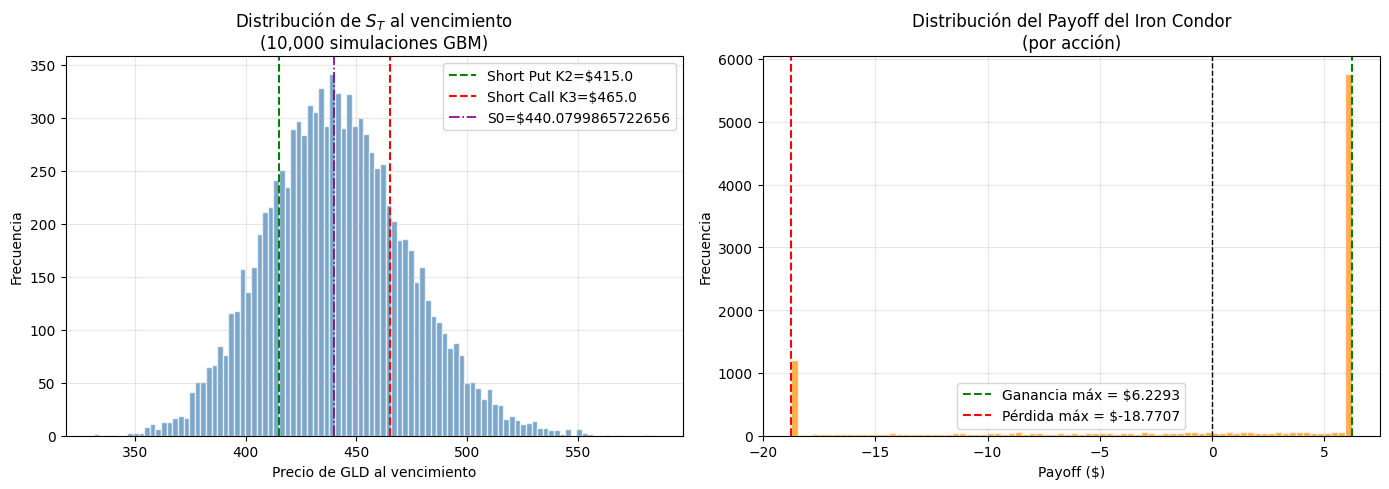

In [ ]:
# Gráfica distribución de ST con zona de ganancia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ST, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(K2, color='green', linestyle='--', linewidth=1.5, label=f'Short Put K2=${K2}')
axes[0].axvline(K3, color='red',   linestyle='--', linewidth=1.5, label=f'Short Call K3=${K3}')
axes[0].axvline(S0, color='purple',linestyle='-.',  linewidth=1.2, label=f'S0=${S0}')
axes[0].set_title('Distribución de $S_T$ al vencimiento\n(10,000 simulaciones GBM)')
axes[0].set_xlabel('Precio de GLD al vencimiento')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(payoffs, bins=80, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].axvline(credito_neto, color='green', linewidth=1.5,
                linestyle='--', label=f'Ganancia máx = ${credito_neto:.4f}')
axes[1].axvline(-perdida_max, color='red', linewidth=1.5,
                linestyle='--', label=f'Pérdida máx = ${-perdida_max:.4f}')
axes[1].set_title('Distribución del Payoff del Iron Condor\n(por acción)')
axes[1].set_xlabel('Payoff ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ANÁLISIS DE SENSIBILIDAD

sigmas_test = [0.20, 0.25, 0.27, 0.30, 0.35]
resultados_sens = []

for sig in sigmas_test:
    np.random.seed(42)
    Z_s  = np.random.normal(0, 1, num_simulations)
    ST_s = S0 * np.exp((r - 0.5 * sig**2) * T + sig * np.sqrt(T) * Z_s)
    payoffs_s = np.array([payoff_condor_scalar(s) for s in ST_s])

    # Recalcular crédito con nueva sigma
    p_k2 = bs_price(S0, K2, r, T, sig, "put")
    p_k1 = bs_price(S0, K1, r, T, sig, "put")
    c_k3 = bs_price(S0, K3, r, T, sig, "call")
    c_k4 = bs_price(S0, K4, r, T, sig, "call")
    cred = (p_k2 - p_k1) + (c_k3 - c_k4)

    resultados_sens.append({
        "σ":                      f"{sig:.0%}",
        "Crédito neto ($)":       round(cred, 4),
        "Prob. éxito (%)":        round(np.mean((ST_s >= K2) & (ST_s <= K3)) * 100, 2),
        "Valor esperado ($)":     round(np.mean(payoffs_s), 4),
        "% Escenarios ganancia":  round(np.mean(payoffs_s > 0) * 100, 2),
    })

df_sens = pd.DataFrame(resultados_sens)
print("\n" + "=" * 60)
print("ANÁLISIS DE SENSIBILIDAD — Variando Volatilidad (σ)")
print("=" * 60)
print(df_sens.to_string(index=False))


ANÁLISIS DE SENSIBILIDAD — Variando Volatilidad (σ)
  σ  Crédito neto ($)  Prob. éxito (%)  Valor esperado ($)  % Escenarios ganancia
20%            3.6738            68.46              2.5133                  78.83
25%            5.9508            58.13              0.2288                  68.53
27%            6.8119            54.55             -0.6299                  64.84
30%            8.0208            49.99             -1.8378                  59.97
35%            9.7996            43.64             -3.6008                  52.99


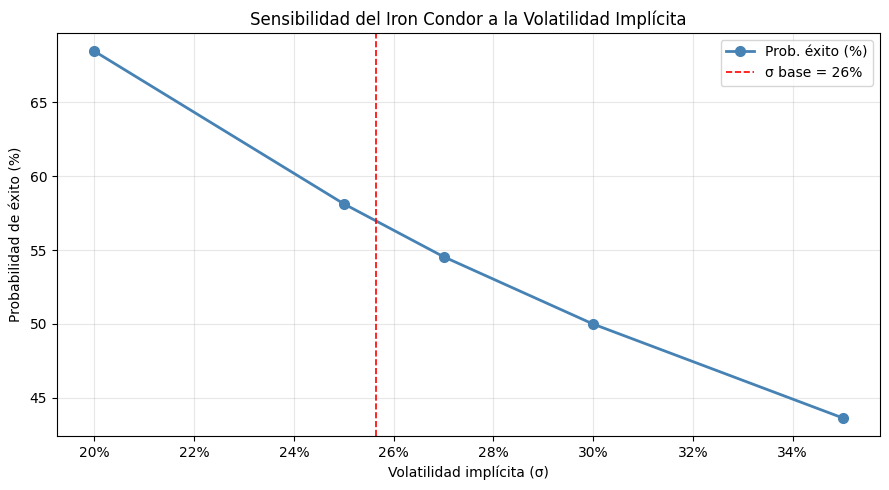

In [ ]:
# Gráfica de sensibilidad
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sigmas_test, df_sens["Prob. éxito (%)"], marker='o',
        color='steelblue', linewidth=2, markersize=7, label='Prob. éxito (%)')
ax.axvline(sigma, color='red', linestyle='--', linewidth=1.2,
           label=f'σ base = {sigma:.0%}')
ax.set_title('Sensibilidad del Iron Condor a la Volatilidad Implícita')
ax.set_xlabel('Volatilidad implícita (σ)')
ax.set_ylabel('Probabilidad de éxito (%)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5075/283098486.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2025-01-01', end='2026-04-17', progress=False)['Close']
/tmp/ipykernel_5075/283098486.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data.loc['2026-04-16'])


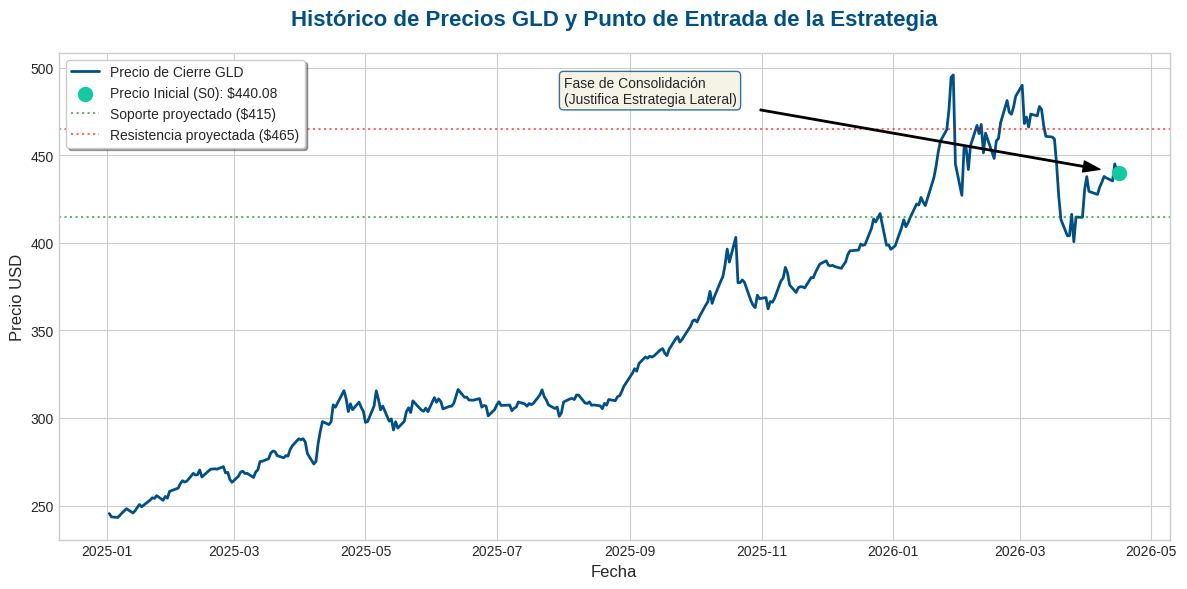

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import numpy as np # Adding this for consistency, though not strictly needed for data download/S0
from datetime import date # Adding this for consistency if date calculation is needed

# Re-defining necessary variables for data loading and S0 calculation
ticker = 'GLD'
fecha_ref = '2026-04-16'
fecha_vencimiento = '2026-05-15'

# Descarga histórica hasta la fecha de referencia
data = yf.download(ticker, start='2025-01-01', end='2026-04-17', progress=False)['Close']

# S0: precio de cierre del 16 de abril de 2026
S0 = float(data.loc['2026-04-16'])

# K2 and K3 are used later in the plot and should be defined
# Assuming these come from cell fSA_86ol2LUg or WFSJy8Jk2bbl, defining them here for self-containment
K2 = 415.0
K3 = 465.0

# 1. Configurar estilo profesional
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio
plt.figure(figsize=(12, 6))

# 2. Graficar la serie de tiempo (usando los datos que ya descargaste en tu notebook)
plt.plot(data.index, data.values, color='#005088', linewidth=2, label='Precio de Cierre GLD')

# 3. Resaltar el Precio Spot (S0) al 16 de abril de 2026
fecha_ref_dt = pd.to_datetime('2026-04-16')
plt.scatter(fecha_ref_dt, S0, color='#11caa0', s=100, zorder=5, label=f'Precio Inicial (S0): ${S0:.2f}')

# 4. Añadir líneas de referencia para mostrar el rango lateral esperado
# Usamos los strikes cortos K2 y K3 para mostrar la "zona de ganancia" proyectada
plt.axhline(y=K2, color='green', linestyle=':', alpha=0.6, label=f'Soporte proyectado (${K2:.0f})')
plt.axhline(y=K3, color='red', linestyle=':', alpha=0.6, label=f'Resistencia proyectada (${K3:.0f})')

# 5. Personalización estética
plt.title('Histórico de Precios GLD y Punto de Entrada de la Estrategia', fontsize=16, fontweight='bold', pad=20, color='#005088')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio USD', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)

# 6. Anotación de justificación
plt.annotate('Fase de Consolidación\n(Justifica Estrategia Lateral)',
             xy=(fecha_ref_dt, S0),
             xytext=(pd.to_datetime('2025-08-01'), 480),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="#f3f0df", ec="#005088", alpha=0.8))

plt.tight_layout()
plt.show()